In [3]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [ ]:
## Single gene-trait association plot
gene_name = 'LDLR'  # Kircher: [231, 87]
gene_name = 'GP1BB' # Kircher: [273, 112]

In [162]:
# Configuration and paths
min_range = -0
max_range = +112

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",-1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",-1
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1


In [163]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet").filter(pl.col('gene_name') == gene_name)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
group_name = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == group_name
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno_wide = (
    anno
    .filter(
        # filter_expression
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

# Create a lazy frame with the unique keys
anno_keys = anno_wide.select(pl.col('id').unique()).lazy()

# Get gene_id to get olink protein
olink_prot = anno_wide['region'].unique()[0] + '_olink'

anno_wide

relative_cds_position,TSS,promoterai,zooverphylop,delta_score,gpn_star_llr_calibrated_mean,id,dist_to_tss,loftee_hc,am_pathogenicity,verphylop,absplice_dna_max,gpn_score,esmscoremissense,gene_name,absplice2_max,region,gene_length,mamphylop,cadd_raw,Strand,abexp_min,pangolin_score
f32,i64,f32,f32,f32,f64,str,i64,i8,f32,f32,f32,f32,f32,str,f32,str,i64,f32,f32,cat,f64,f32
0.0,19723538,0.021,-0.078,0.01,0.675772,"""chr22:19723643:C:T""",105,0,0.0,0.658,0.003,-1.6,0.0,"""GP1BB""",0.000328,"""ENSG00000203618""",1234,-0.041,0.458488,"""+""",-0.015897,0.0
0.0,19723538,-0.0876,-1.117,0.01,-1.407681,"""chr22:19723628:G:A""",90,0,0.0,-1.832,0.003,0.65,0.0,"""GP1BB""",0.002216,"""ENSG00000203618""",1234,-1.075,0.013377,"""+""",-0.040499,0.02
0.0,19723538,-0.0329,0.015,0.07,-0.896351,"""chr22:19723630:G:C""",92,0,0.0,0.122,0.005,-1.74,0.0,"""GP1BB""",0.000495,"""ENSG00000203618""",1234,0.246,0.419361,"""+""",-0.0312,0.01
0.0,19723538,-0.0281,-0.703,0.0,-0.906384,"""chr22:19723616:C:T""",78,0,0.0,-0.277,0.003,-1.68,0.0,"""GP1BB""",0.002358,"""ENSG00000203618""",1234,-0.968,0.412942,"""+""",-0.01673,0.01
0.0,19723538,-0.0343,0.577,0.0,-1.166398,"""chr22:19723601:G:C""",63,0,0.0,-0.143,0.004,-0.8,0.0,"""GP1BB""",0.002576,"""ENSG00000203618""",1234,0.932,0.776507,"""+""",-0.027602,0.01
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,19723538,-0.0594,-0.948,0.0,-3.107656,"""chr22:19723546:A:T""",8,0,0.0,-3.817,0.003,-1.14,0.0,"""GP1BB""",0.000308,"""ENSG00000203618""",1234,-1.828,0.261769,"""+""",-0.038315,0.0
0.0,19723538,-0.029,1.013,0.0,0.352908,"""chr22:19723609:C:G""",71,0,0.0,0.014,0.005,-1.65,0.0,"""GP1BB""",0.000412,"""ENSG00000203618""",1234,-0.522,0.610496,"""+""",-0.048921,0.0
0.0,19723538,-0.0324,0.96,0.06,-2.735259,"""chr22:19723587:T:C""",49,0,0.0,0.092,0.005,-3.91,0.0,"""GP1BB""",0.003095,"""ENSG00000203618""",1234,0.719,1.493826,"""+""",-0.111893,0.03


In [164]:
# new_anno = pl.scan_parquet("/home/dnanexus/data_dir/abexp1.1_annotations_all_ukb_vars_genebass1e6.parquet")
# # new_anno.head().collect()
# new_anno = new_anno.select(['id', 'region', 'abexp_whole_blood']).collect()
# new_anno = new_anno.filter(pl.col('abexp_whole_blood').is_not_null())

# anno_wide = anno_wide.join(new_anno, on=['id', 'region'], how='left').filter(pl.col('abexp_whole_blood').is_not_null())

# existing_annos += ['abexp_whole_blood']

# anno_wide

In [165]:
melted_anno = anno_wide.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr22:19723643:C:T""","""ENSG00000203618""","""loftee_hc""",0.0
"""chr22:19723628:G:A""","""ENSG00000203618""","""loftee_hc""",0.0
"""chr22:19723630:G:C""","""ENSG00000203618""","""loftee_hc""",0.0
"""chr22:19723616:C:T""","""ENSG00000203618""","""loftee_hc""",0.0
"""chr22:19723601:G:C""","""ENSG00000203618""","""loftee_hc""",0.0
…,…,…,…
"""chr22:19723546:A:T""","""ENSG00000203618""","""abexp_min""",-0.038315
"""chr22:19723609:C:G""","""ENSG00000203618""","""abexp_min""",-0.048921
"""chr22:19723587:T:C""","""ENSG00000203618""","""abexp_min""",-0.111893


In [166]:
# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

olink_appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('olink_prot') == olink_prot)
    )
)

# Merge olink, phenotype, and annotation data
og_df = (
    olink_appv
    .join(
        melted_anno.lazy(),
        on="id",
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(),
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

og_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr22:19723643:C:T""","""ENSG00000203618_olink""",1,-0.174037,null,"""ENSG00000203618""","""cadd_raw""",0.458488,19723538,"""+""",1234,"""GP1BB""",105
"""chr22:19723643:C:T""","""ENSG00000203618_olink""",1,-0.174037,null,"""ENSG00000203618""","""loftee_hc""",0.0,19723538,"""+""",1234,"""GP1BB""",105
"""chr22:19723643:C:T""","""ENSG00000203618_olink""",1,-0.174037,null,"""ENSG00000203618""","""am_pathogenicity""",0.0,19723538,"""+""",1234,"""GP1BB""",105
"""chr22:19723643:C:T""","""ENSG00000203618_olink""",1,-0.174037,null,"""ENSG00000203618""","""esmscoremissense""",0.0,19723538,"""+""",1234,"""GP1BB""",105
"""chr22:19723643:C:T""","""ENSG00000203618_olink""",1,-0.174037,null,"""ENSG00000203618""","""gpn_star_llr_calibrated_mean""",0.675772,19723538,"""+""",1234,"""GP1BB""",105
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:19723609:C:G""","""ENSG00000203618_olink""",1,0.235141,null,"""ENSG00000203618""","""pangolin_score""",0.0,19723538,"""+""",1234,"""GP1BB""",71
"""chr22:19723609:C:G""","""ENSG00000203618_olink""",1,0.235141,null,"""ENSG00000203618""","""absplice2_max""",0.000412,19723538,"""+""",1234,"""GP1BB""",71
"""chr22:19723609:C:G""","""ENSG00000203618_olink""",1,0.235141,null,"""ENSG00000203618""","""abexp_min""",-0.048921,19723538,"""+""",1234,"""GP1BB""",71


In [167]:
# Join with experimental data
exp_data = pl.read_csv('/home/dnanexus/data_dir/exp_data/kircher_all_enhancers_and_promoters.tsv', separator='\t').rename({
    'locus': 'gene_name'
}).with_columns(
    id=pl.col('Chromosome')+':'+pl.col('variant_pos').cast(pl.Utf8)+':'+pl.col('ref')+':'+pl.col('alt')
).select(
    ['gene_name', 'id', 'log2FC', 'variant_pos']
).unique().filter(
    pl.col('gene_name') == gene_name
)

# exp_data['variant_pos'].min()

# Merge phenodata with exp_data
og_df = og_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
og_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,gene_name_right,log2FC,variant_pos
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,f64,i64
"""chr22:19723633:G:A""","""ENSG00000203618_olink""",2,-1.223499,0.824782,"""ENSG00000203618""","""cadd_raw""",0.258141,19723538,"""+""",1234,"""GP1BB""",95,"""GP1BB""",-0.02,19723633
"""chr22:19723633:G:A""","""ENSG00000203618_olink""",2,-1.223499,0.824782,"""ENSG00000203618""","""loftee_hc""",0.0,19723538,"""+""",1234,"""GP1BB""",95,"""GP1BB""",-0.02,19723633
"""chr22:19723633:G:A""","""ENSG00000203618_olink""",2,-1.223499,0.824782,"""ENSG00000203618""","""am_pathogenicity""",0.0,19723538,"""+""",1234,"""GP1BB""",95,"""GP1BB""",-0.02,19723633
"""chr22:19723633:G:A""","""ENSG00000203618_olink""",2,-1.223499,0.824782,"""ENSG00000203618""","""esmscoremissense""",0.0,19723538,"""+""",1234,"""GP1BB""",95,"""GP1BB""",-0.02,19723633
"""chr22:19723633:G:A""","""ENSG00000203618_olink""",2,-1.223499,0.824782,"""ENSG00000203618""","""gpn_star_llr_calibrated_mean""",-1.364229,19723538,"""+""",1234,"""GP1BB""",95,"""GP1BB""",-0.02,19723633
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:19723629:G:A""","""ENSG00000203618_olink""",5,-0.638705,0.273013,"""ENSG00000203618""","""pangolin_score""",0.03,19723538,"""+""",1234,"""GP1BB""",91,"""GP1BB""",0.02,19723629
"""chr22:19723629:G:A""","""ENSG00000203618_olink""",5,-0.638705,0.273013,"""ENSG00000203618""","""absplice2_max""",0.002629,19723538,"""+""",1234,"""GP1BB""",91,"""GP1BB""",0.02,19723629
"""chr22:19723629:G:A""","""ENSG00000203618_olink""",5,-0.638705,0.273013,"""ENSG00000203618""","""abexp_min""",-0.01673,19723538,"""+""",1234,"""GP1BB""",91,"""GP1BB""",0.02,19723629


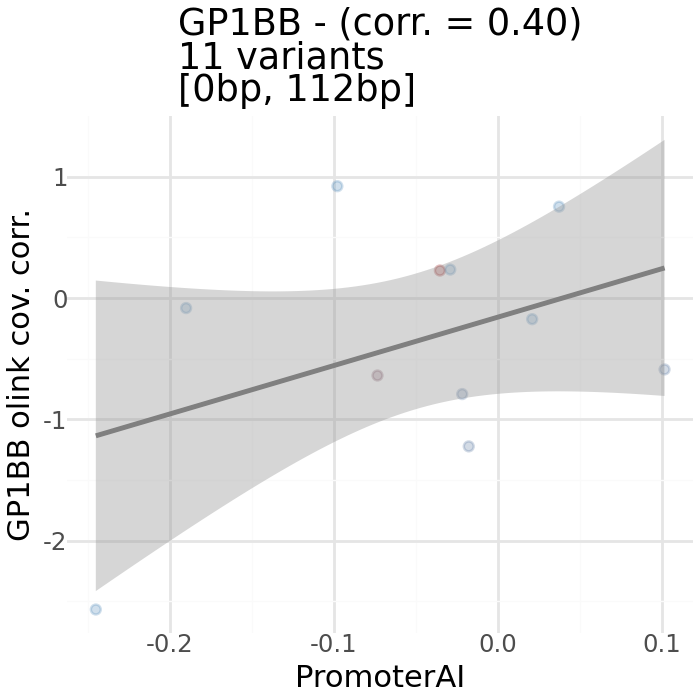

In [171]:
# annotation = 'gpn_star_llr_calibrated_mean'
# annotation = 'gpn_score'
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants \
        \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(3.5, 3.5),
        legend_position='none'
    )
)

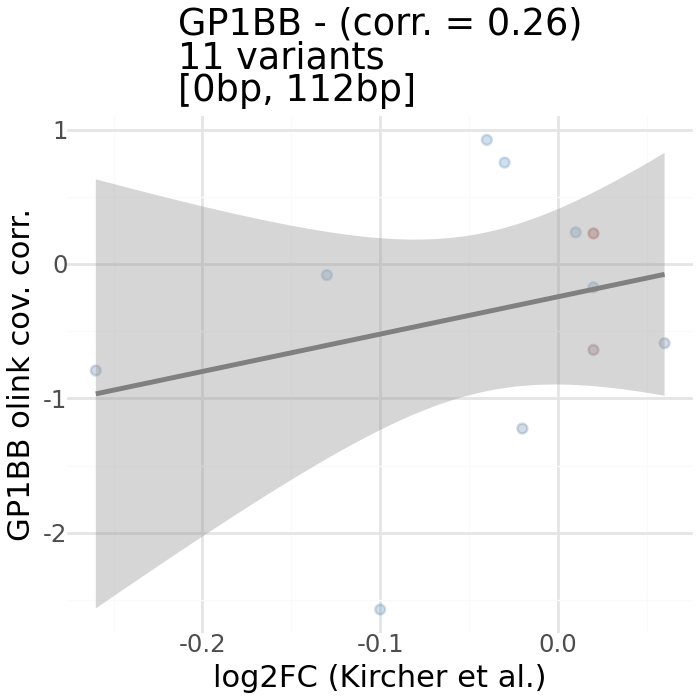

In [169]:

plot_df = (
    og_df
    .select(['id', 'log2FC', 'mean_olink_value', 'n_individuals'])
    .unique()
    # .filter(
    #     (pl.col('annotation') == annotation)
    # )
)

(
    ggplot(plot_df, aes(x='log2FC', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"log2FC (Kircher et al.)",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('log2FC', 'mean_olink_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants \
        \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(3.5, 3.5),
        legend_position='none'
    )
)

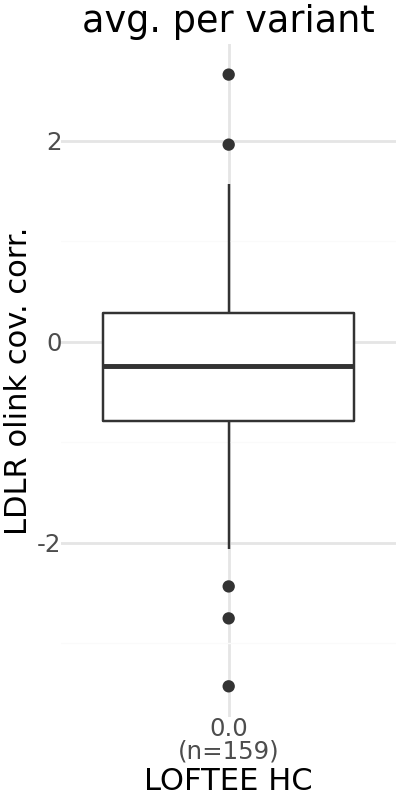

In [13]:
annotation = 'loftee_hc'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

summary_labels = (
    plot_df
    .group_by(['annotation_score'])
    .agg(n_vars = pl.col('id').len())
    .with_columns(n_label = pl.col('annotation_score').cast(pl.Utf8) + '\n(n=' + pl.col('n_vars').cast(pl.Utf8) + ')')
)

plot_df = plot_df.join(summary_labels, on='annotation_score', how='left')

(
    ggplot(plot_df, aes(x='n_label', y='mean_olink_value')) +
    geom_boxplot(aes(group='n_label')) +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title="avg. per variant"
    ) +
    theme(figure_size=(2, 4))
)

In [33]:
phenotype = 'ldl_direct_int'

# Merge olink, genotype and phenotype data
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

appv = (
    appv
    .join(
        og_df[['id']].unique().lazy(), on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('phenotype') == phenotype)
    )
)

ogp_df = (
    og_df.lazy()
    .join(
            appv,
            on="id",
            how="inner"
    )
    .collect(engine='streaming')
    .rename({
        'n_individuals_right': 'n_individuals_appv',
    })
)

ogp_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,phenotype,n_individuals_appv,mean_pheno_value,std_pheno_value
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,u32,f32,f32
"""chr19:11089502:G:T""","""ENSG00000130164_olink""",1,-0.055333,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",0.25179,11089461,"""+""",44360,"""LDLR""",41,"""ldl_direct_int""",1,-0.019057,null
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.707564,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089364:C:T""","""ENSG00000130164_olink""",1,0.540594,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.787185,11089461,"""+""",44360,"""LDLR""",-97,"""ldl_direct_int""",2,0.063061,0.10452
"""chr19:11089474:G:A""","""ENSG00000130164_olink""",1,0.952203,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-1.547741,11089461,"""+""",44360,"""LDLR""",13,"""ldl_direct_int""",1,0.081006,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089523:G:A""","""ENSG00000130164_olink""",1,-0.8685,null,"""ENSG00000130164""","""promoterai_abs""",0.0621,11089461,"""+""",44360,"""LDLR""",62,"""ldl_direct_int""",3,0.112577,0.863519
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_abs""",0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_under""",-0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918


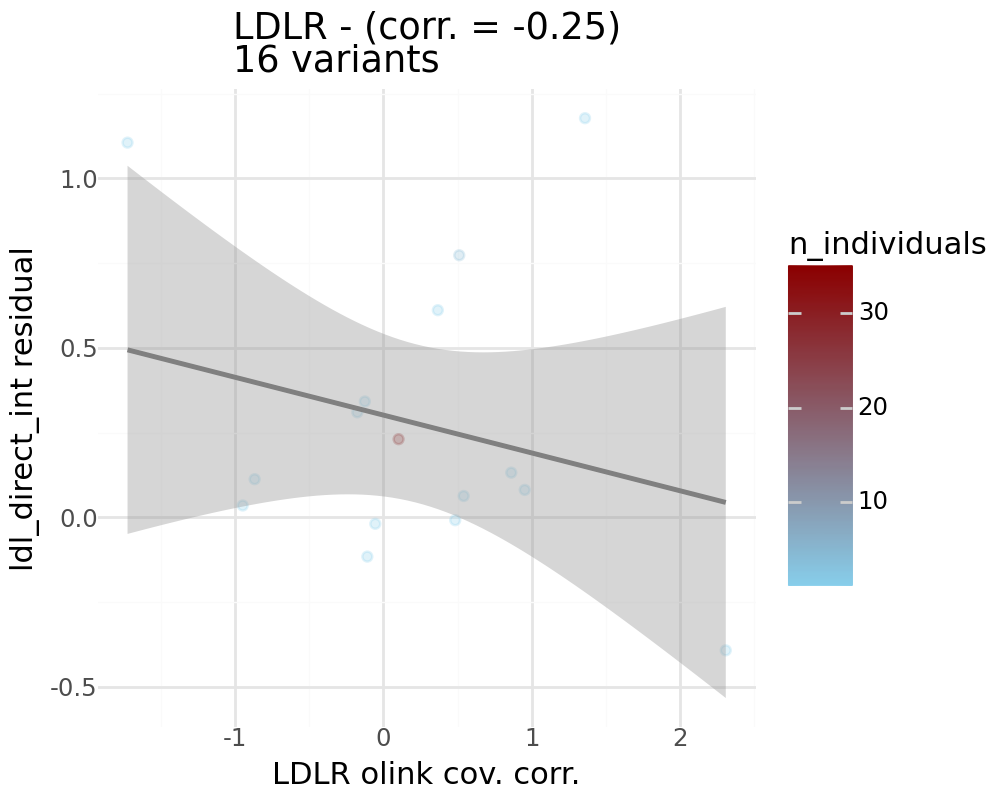

In [34]:
plot_df = ogp_df[['id', 'mean_olink_value', 'mean_pheno_value', 'n_individuals']].unique()

(
    ggplot(plot_df, aes(x='mean_olink_value', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{gene_name} olink cov. corr.",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('mean_olink_value', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


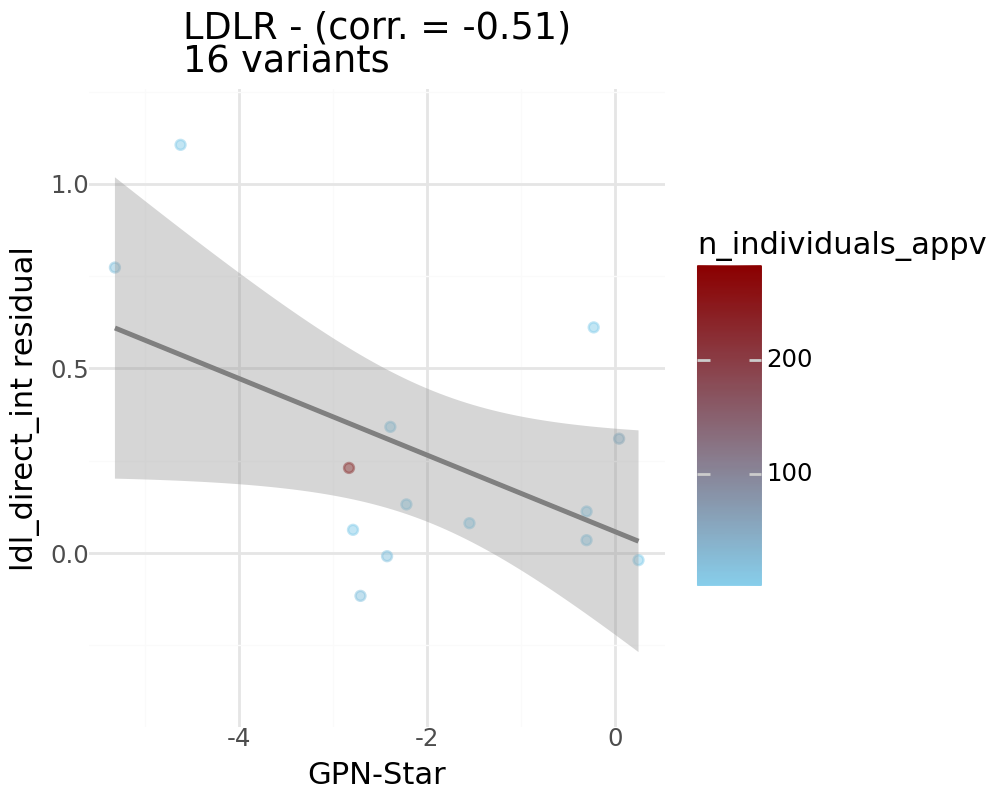

In [36]:
annotation = 'gpn_star_llr_calibrated_mean'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    ogp_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals_appv')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)